## Lecture 14 - Clustering

### Cross validation 

When do we know which model to choose within machine learning?

Usually, to test a model we set aside 25% of the data to be used for testing the data later on. The other 75% is used for training the model so that it can estimate the parameters.

We can compare methods by seeing how well each one categorised the test data.

But which 25% should we be taking out? The last 25%, what about the first one, or the two middle 25%?

Cross validation uses them all, one at a time and then summarises the results at the end.

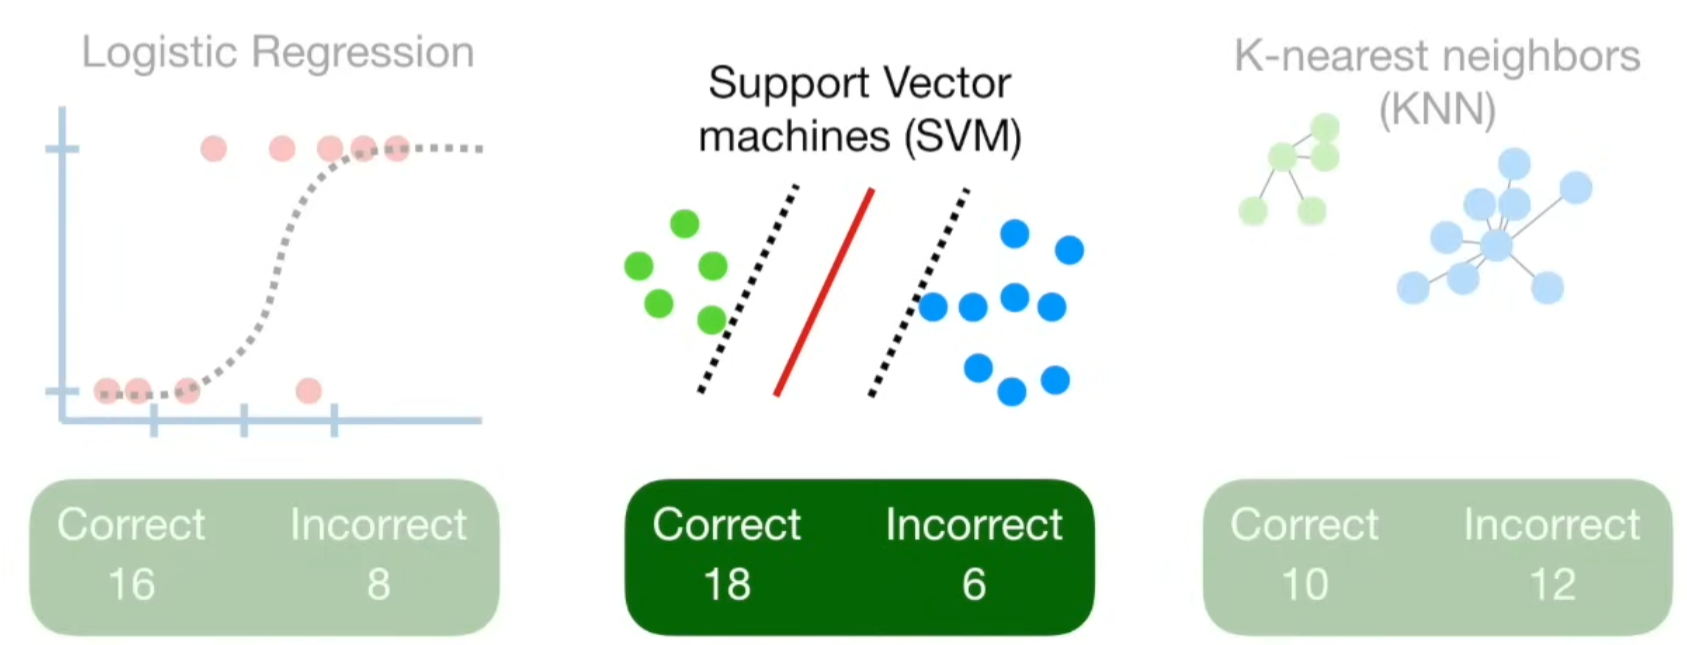



In this case we can see that the SVM did the best for classification, we can use that one.

We could also divide the data into different blocks, for 4 blocks it is called the four-fold cross validation.

So in an extreme case, we can use "leave one out cross validation" where each sample is left out individually. But the most common is to use a ten fold cross validation



#### What if we want to try to find the best parameters too?

Then we can also set aside another slice of the training data, as a **validation set**.

Just to recap we have the following:

- **Training** data are used for the actual fit
- **Validation** data are used to optimize the parameters of the algorithm (tune the hyperparameters)
- **Test** data are used at the very end to evaluate the overall performance.



So remember when we were talking about determining the best bandwidth for kernel density estimation? We can use GridSearchCV for this, and replot our histogram:

In [2]:
import numpy as np
import scipy.stats as stats
import pylab as plt 


np.random.seed(0)
N = 1000
mu_gamma_f = [(5, 1.0, 0.1),
              (7, 0.5, 0.5),
              (9, 0.1, 0.1),
              (12, 0.5, 0.2),
              (14, 1.0, 0.1)]
true_pdf = lambda x: sum([f * stats.cauchy(mu, gamma).pdf(x)
                          for (mu, gamma, f) in mu_gamma_f])
x = np.concatenate([stats.cauchy(mu, gamma).rvs(int(f * N))
                    for (mu, gamma, f) in mu_gamma_f])
np.random.shuffle(x)
x = x[x > -10]
x = x[x < 30]


We can see here, that our lambda function is just taking each column to be mu, gamma and f, and then calculating a cauchy pdf using these values.

Let us plot this, remember we are putting a smooth distribution for each of the observed data points and then adding them up to form the full distribution. The bandwidth controls the width of each gaussian (for this instance we are using gaussians)

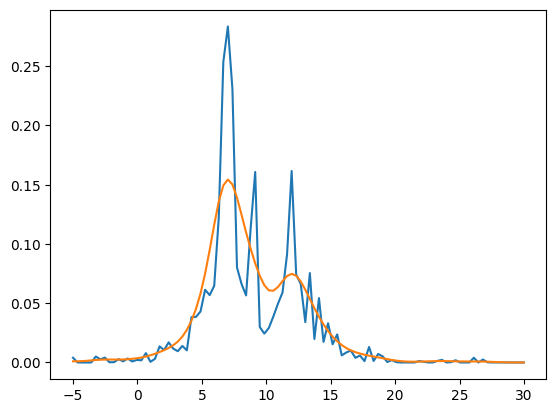

In [3]:
from sklearn.neighbors import KernelDensity

def kde_sklearn(data, bandwidth = 1.0):
    kde_skl = KernelDensity(bandwidth = bandwidth) # This is the estimator
    kde_skl.fit(data[:, np.newaxis]) # This fits it
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

xgrid =np.linspace(-5,30,100)
pdf = kde_sklearn(x,bandwidth=0.1)
plt.plot(xgrid,pdf)
pdf = kde_sklearn(x,bandwidth=1)
plt.plot(xgrid,pdf)

Now we implement cross validation to choose from the data, where GridSearchCV exhaustively tries the parameter values given to it. if cv = 5, then we are using a 5 fold cross validaiton.

In [4]:
from sklearn.model_selection import GridSearchCV

bwrange = np.linspace(0.01,1.0, 40) # Test 30 bandwidths from 0.1 to 1.0
print(bwrange)
K = 5 # Do 5-fold cross validation
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
grid.fit(x[:, None]) #Fit the histogram data that we started the lecture with.
h_opt = grid.best_params_['bandwidth']
print(h_opt)

[0.01       0.03538462 0.06076923 0.08615385 0.11153846 0.13692308
 0.16230769 0.18769231 0.21307692 0.23846154 0.26384615 0.28923077
 0.31461538 0.34       0.36538462 0.39076923 0.41615385 0.44153846
 0.46692308 0.49230769 0.51769231 0.54307692 0.56846154 0.59384615
 0.61923077 0.64461538 0.67       0.69538462 0.72076923 0.74615385
 0.77153846 0.79692308 0.82230769 0.84769231 0.87307692 0.89846154
 0.92384615 0.94923077 0.97461538 1.        ]
0.41615384615384615


This tried all the bandwidths and returened the best one. For more complicated situations we may need a root finder.

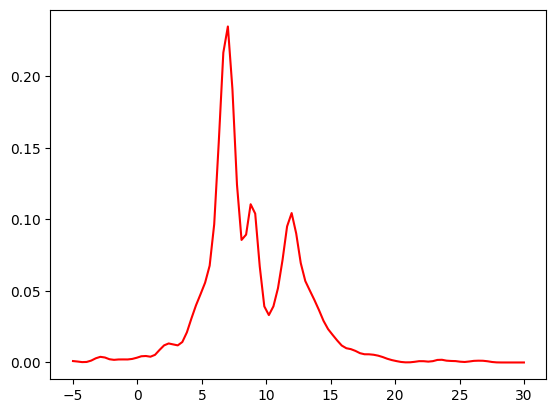

In [5]:
pdf = kde_sklearn(x,bandwidth=h_opt)
plt.plot(xgrid,pdf,c='red');

## Clustering

The clustering process attempts to group together similar objects within a data set. This is an unsupervised process, and allows us to put new objects into the formed classes, and to identify rare objects that do not fit the mold set.



### K-means Clustering

K-means minimises the following:

$$\sum_{k=1}^{K}\sum_{i\in C_k}||x_i - \mu_k||^2$$

where

$$\mu_k = \frac{1}{N_k}\sum_{i\in C_k} x_i$$

The later recipe will show a simplified version, the more mathematical is:
1. Take every object in class $C_k$ determined by which centroid it is closest to, specifically $C_k(x_i) = \arg \min_k (||x_i-\mu_k||)$
2. Compute the mean of the objects in the class
3. Subtract the mean from each member of that class and square the norm
4. Do that for each class and sum
5. Shift the centroids of the pre-determined number of classes until this sum is minimised
6. Do this multiple times wiht different starting centroids and take the result with the minimum sum

We start with raw data, and then have kmeans clustering find the clusters within the data, it works as follows:

1. Select the number of clusters you wish to identify in your data, (This is the K in K-means)

2. Randomly select 3 distinct data points, these are the initial clusters

3. Measure the distance between the 1st point and the 3 initial clusters

4. Assign the 1st point to the nearest cluster and then repeat with all points

5. Calculate the mean of each cluster

6. Use the mean values to measure and cluster as we did before, if it doesn't change, we are done.

You do this all again a few times with different starting points, and keep a note of the total variation between the clusters

#### What value of K should we use?

You can just try different values of K and see what happens. You can quantify how much better each K value is by comparing the total variation within the clusters to the previous K value

And then we can plot the following:

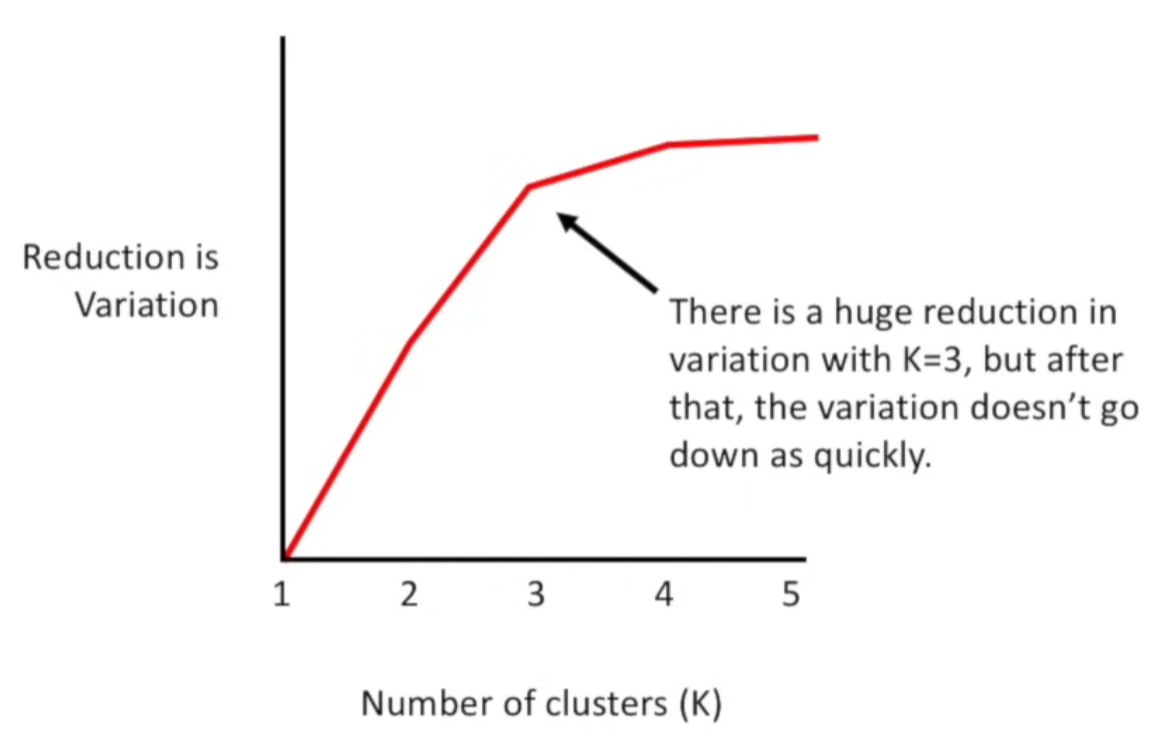





This is an elbow plot, and you can find what K you should choose by finding the elbow in the plot.

#### What if the data is a heatmap?

Then you can just plot the samples on an x-y graph and cluster as before.

But all it depends on is just the distance between the samples. So when we have 2 samples/2 axis, we can just use

$$\sqrt{x^2 + y^2}$$

When it is 3 samples/ 3 axis, we can use:

$$\sqrt{x^2 + y^2 + z^2}$$

etc etc

Let us apply this to code:

[[ 1.06793353  0.18182003]
 [ 0.02104861  0.27303361]
 [ 0.93731937 -0.56584771]
 ...
 [ 3.39886152 -3.20372411]
 [ 3.08796466 -3.01232455]
 [ 5.27034314 -2.19865198]]


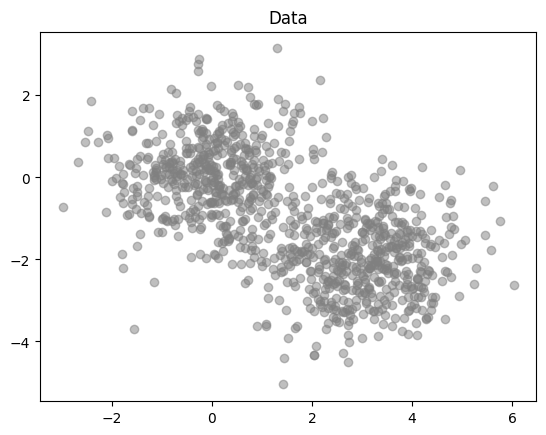

In [12]:
# Generate mock data

mode1= np.random.normal(size=(500,2))
mode2= np.random.normal(loc=[3.0,-2.0], size=(500,2))

#X = np.random.normal(size=(1000,2)) #1000 points in 2D
X = np.concatenate([mode1,mode2]) # 1000  points in 2D
print(X)
plt.title('Data')
plt.scatter(X[:,0],X[:,1],color='gray',alpha=0.5)

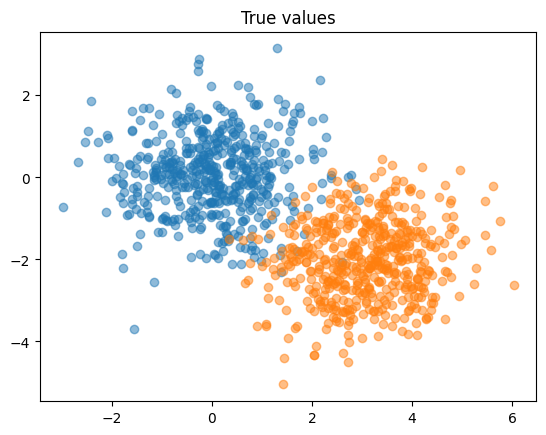

In [13]:
plt.title('True values')
plt.scatter(mode1[:,0],mode1[:,1],color='C0',alpha=0.5)
plt.scatter(mode2[:,0],mode2[:,1],color='C1',alpha=0.5);

So these are the true values, let us see why SciKit learn gets us:

0


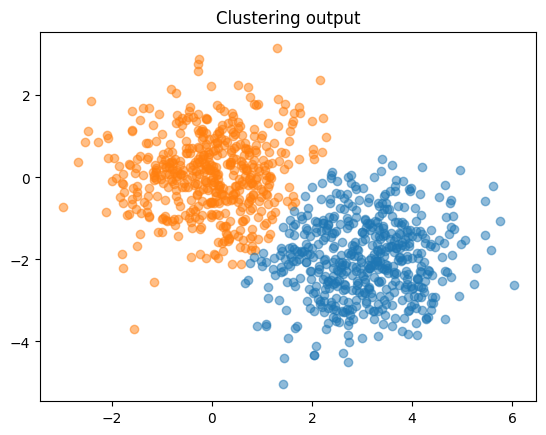

In [26]:
from sklearn.cluster import KMeans
from sklearn import preprocessing

clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(2):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.5)


plt.title('Clustering output');

print(labels[20])


In [38]:
from sklearn.metrics import confusion_matrix

true_labels = np.concatenate([np.zeros(500, dtype=int), np.ones(500, dtype=int)])

cm = confusion_matrix(true_labels, labels)

print(cm)

[[480  20]
 [  7 493]]


This is the confusion matrix, this for example means that 480 where generated from mode 0 and assigned to cluster 0, the 20 shows that they were generated from mode 0 but assigned to cluster 1.

#### Let us try Kmeans with multidimensional data

In [35]:
# Execute the next few cells
from astropy.table import Table
t = Table.read('../Data/cruz_all_dist.dat', format="ascii")

# Turn these data into a properly formatted Scikit-Learn array
X = np.vstack([ t['col2'], t['col3'], t['col4'], t['col5'] ]).T
print(X)

[[13.03636039 -0.11023487  9.04241732  0.        ]
 [13.33267828 -0.10360584  9.35453197  0.68184119]
 [13.14338559 -0.16142859  9.30932842  0.82017946]
 ...
 [ 6.77437708 -0.12553107  5.54210446  7.41862726]
 [ 6.71834403  0.04474092  5.56965196  7.44040775]
 [ 7.02729337  0.12547728  5.55979252  7.49615526]]


Use PCA to project the data onto 2 axes:

Text(0, 0.5, 'Eigenvalue 2')

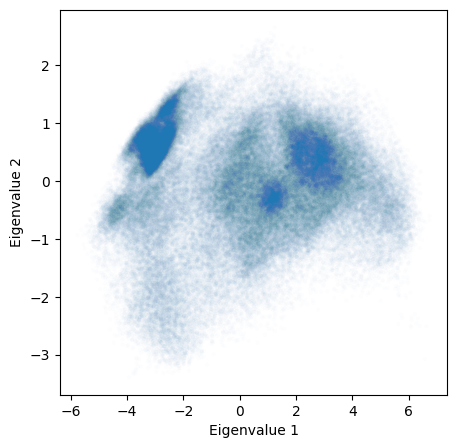

In [39]:
# Project onto 2 axes with PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2) # 2 components
pca.fit(X) # Do the fitting


fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()


X_reduced = pca.transform(X)

ax.scatter(X_reduced[:,0], X_reduced[:,1], 
            marker=".", color='C0', 
            alpha=0.01, edgecolors='None')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

This shows the data being projected into two linear combinations that encompass the direction of greatest variance. Let us do Kmeans in these dimensions

In [40]:
n_cluster = 6
scaler = preprocessing.StandardScaler()
clf = KMeans(n_cluster, n_init = "auto" )
clf.fit(scaler.fit_transform(X_reduced))

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


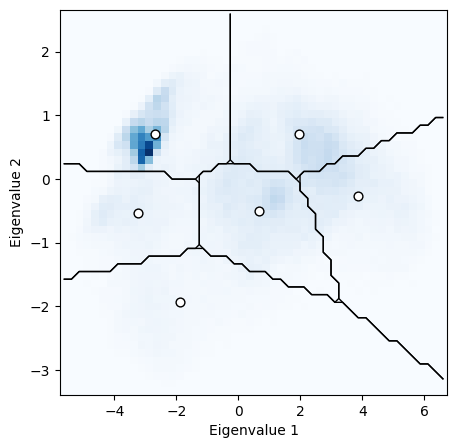

In [42]:
# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X_reduced[:,0], X_reduced[:,1], 50) # the 50 at the end divided the plane into 50 x 50 rectangular cells

# plot density map
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1],
                  yedges[0], yedges[-1]],
          cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(clf.cluster_centers_) # undo the scaling we did initially
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 50 * 50)).T

H = clf.predict(scaler.transform(Xgrid)).reshape((50, 50))

for i in range(n_cluster):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5],
               linewidths=1, colors='k')

    H = clf.predict(scaler.transform(Xgrid)).reshape((50, 50))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('Eigenvalue 1')
ax.set_ylabel('Eigenvalue 2')

plt.show()

The above figure displays the underlying density of samples, the cluster centers, and the cluster boundaries

### Mean-Shift Clustering

This finds the modes in a kernel density estimator of the distribution, and we use the mean shift algorithm:

1. The KDE of the dataset is computed using a specified bandwidth
2. Calculate the gradient of the density distribution, this is easy to do with smooth kernels like gaussians
3. Each data point is iteratively shifted in the direction of the steepest density gradient (the peaks) which drives the points to the modes
4. This process continues until all points have converged at local modes of high density
5. The data points that converge to the same mode (or peak) are grouped into the same cluster

Let us try this out!

In [44]:
# Compute the Mean-shift clustering
from sklearn.cluster import MeanShift

scaler = preprocessing.StandardScaler()
bandwidth = 0.4
#bandwidth = estimate_bandwidth(X_reduced) # this takes a long time...beware
ms = MeanShift(bandwidth=bandwidth, 
               bin_seeding=True, 
               cluster_all=False)
ms.fit(scaler.fit_transform(X_reduced))

,"bandwidth bandwidth: float, default=NoneBandwidth used in the flat kernel.If not given, the bandwidth is estimated usingsklearn.cluster.estimate_bandwidth; see the documentation for thatfunction for hints on scalability (see also the Notes, below).",0.4
,"seeds seeds: array-like of shape (n_samples, n_features), default=NoneSeeds used to initialize kernels. If not set,the seeds are calculated by clustering.get_bin_seedswith bandwidth as the grid size and default values forother parameters.",None
,"bin_seeding bin_seeding: bool, default=FalseIf true, initial kernel locations are not locations of allpoints, but rather the location of the discretized version ofpoints, where points are binned onto a grid whose coarsenesscorresponds to the bandwidth. Setting this option to True will speedup the algorithm because fewer seeds will be initialized.The default value is False.Ignored if seeds argument is not None.",True
,"min_bin_freq min_bin_freq: int, default=1To speed up the algorithm, accept only those bins with at leastmin_bin_freq points as seeds.",1
,"cluster_all cluster_all: bool, default=TrueIf true, then all points are clustered, even those orphans that arenot within any kernel. Orphans are assigned to the nearest kernel.If false, then orphans are given cluster label -1.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. The following tasks benefitfrom the parallelization:- The search of nearest neighbors for bandwidth estimation and label assignments. See the details in the docstring of the ``NearestNeighbors`` class.- Hill-climbing optimization for all seeds.See :term:`Glossary ` for more details.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"max_iter max_iter: int, default=300Maximum number of iterations, per seed point before the clusteringoperation terminates (for that seed point), if has not converged yet... versionadded:: 0.22",300


[-1  0  1  2  3  4  5  6]
0.4
number of estimated clusters : 7


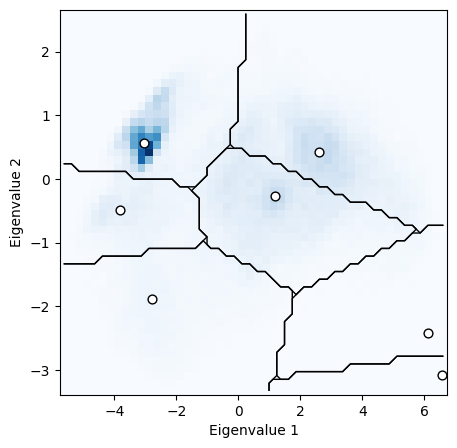

In [45]:
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X_reduced[:,0], X_reduced[:,1], 50)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1],
                  yedges[0], yedges[-1]],
          cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 50 * 50)).T

H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5],
               linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('Eigenvalue 1')
ax.set_ylabel('Eigenvalue 2')

plt.show()

### CODING PRACTICE

Text(0, 0.5, 'Feature 2')

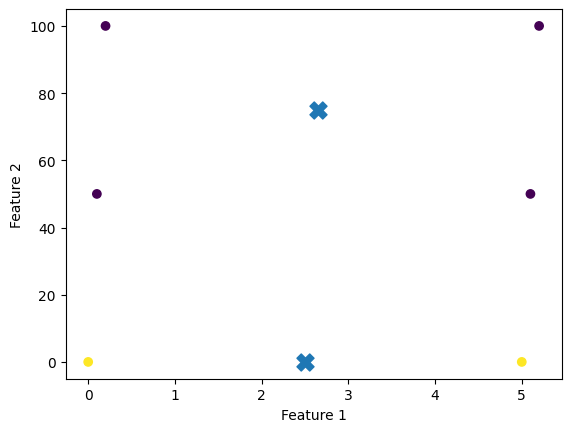

In [54]:
# Use a random dataset

X = np.array([
    [0.0,   0],
    [0.1,  50],
    [0.2, 100],

    [5.0,   0],
    [5.1,  50],
    [5.2, 100]
])

# We can see that the ranges of feature 1 and 2 are vastly different, lets see what happens when we do not normalise:

clf_nonorm = KMeans(n_clusters = 2, n_init = 10, random_state = 1)
clf_nonorm.fit(X)
nonormlabels = clf_nonorm.labels_
nonormcentres = clf_nonorm.cluster_centers_

plt.scatter(X[:,0], X[:,1], c = nonormlabels)
plt.scatter(nonormcentres[:,0], nonormcentres[:,1], s = 150, marker = "X")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")


We can see that Kmeans has ignored the left and right separation

In [55]:
print(nonormlabels)
print(nonormcentres)

[1 0 0 1 0 0]
[[ 2.65 75.  ]
 [ 2.5   0.  ]]


In [60]:
scaler = preprocessing.StandardScaler()

X_scaled = scaler.fit_transform(X)

clf_norm = KMeans(n_clusters= 2, n_init= 10, random_state= 1)

clf_norm.fit(X_scaled)

normlabels = clf_norm.labels_
normcentres_scaled = clf_norm.cluster_centers_

normcentres = scaler.inverse_transform(normcentres_scaled)

print(normlabels)
print(normcentres)
print(scaler.inverse_transform(clf_norm.cluster_centers_))
print(clf_norm.inertia_)


[1 1 1 0 0 0]
[[ 5.1 50. ]
 [ 0.1 50. ]]
[[ 5.1 50. ]
 [ 0.1 50. ]]
6.006393180607351


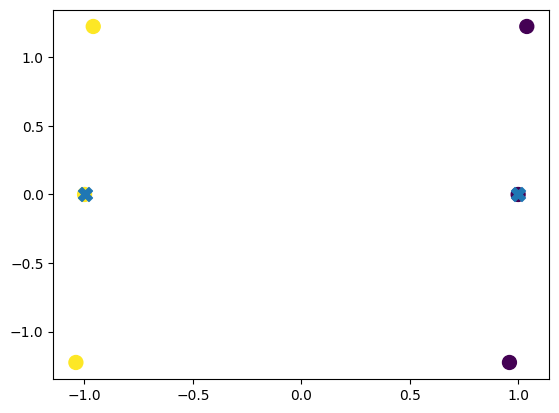

In [69]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c = normlabels, s = 100)
plt.scatter(normcentres_scaled[:,0], normcentres_scaled[:,1], s = 100, marker= "X")

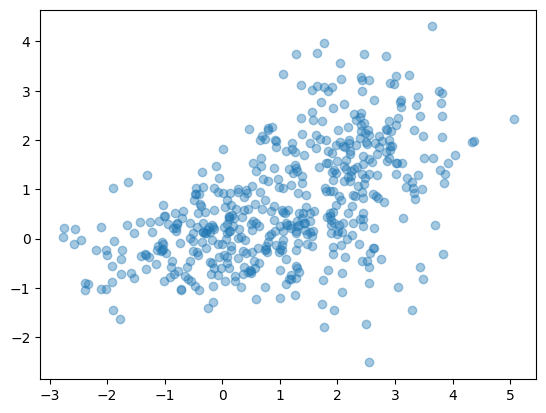

In [76]:
rng = np.random.default_rng(42)

cluster1 = rng.normal(
    loc=[0, 0],
    scale=[1.2, 0.7],
    size=(250, 2)
)

cluster2 = rng.normal(
    loc=[2.2, 1.5],
    scale=[0.9, 1.1],
    size=(250, 2)
)

X = np.concatenate([cluster1, cluster2])


plt.scatter(X[:,0], X[:,1], alpha = 0.4)

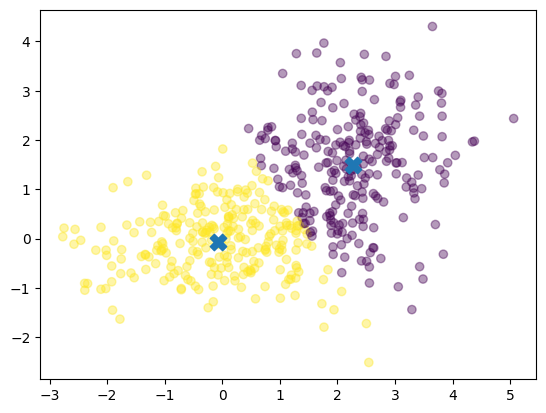

In [80]:
clf = KMeans(n_clusters= 2, n_init = 10, random_state= 1)
clf.fit(X)

labels = clf.labels_
centres = clf.cluster_centers_

plt.scatter(X[:,0], X[:,1], alpha = 0.4, c = labels)
plt.scatter(centres[:,0], centres[:,1], s = 140, marker= "X")

In [83]:
np.count_nonzero(labels)

np.int64(254)

In [84]:
np.bincount(labels)

array([246, 254])

In [85]:
true_labels = np.concatenate([np.zeros(250, dtype = int), np.ones(250, dtype = int)])

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, labels)

print(cm)

[[ 23 227]
 [223  27]]


In [86]:
labels_swapped = 1 - labels

cm = confusion_matrix(true_labels, labels_swapped)

print(cm)

[[227  23]
 [ 27 223]]


In [88]:
accuracy = np.mean(labels_swapped == true_labels)
print(accuracy)

0.9


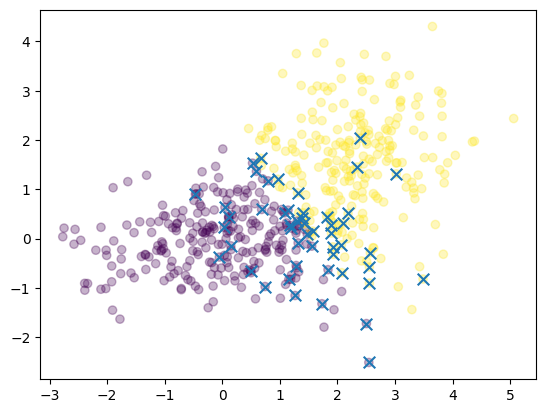

In [89]:
wrong = labels_swapped != true_labels

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels_swapped,
    alpha=0.3
)

plt.scatter(
    X[wrong, 0],
    X[wrong, 1],
    marker="x",
    s=70
)

In [90]:
rng = np.random.default_rng(42)

group1 = rng.normal(
    loc=[0, 0, 0, 0],
    scale=[1.0, 1.0, 0.5, 2.0],
    size=(300, 4)
)

group2 = rng.normal(
    loc=[2.0, 1.5, 1.0, 3.0],
    scale=[1.0, 0.8, 0.7, 1.5],
    size=(300, 4)
)

X4 = np.concatenate([group1, group2])

In [91]:
print(X4.shape)

(600, 4)


In [97]:
scalar = preprocessing.StandardScaler()
X4_scaled = scalar.fit_transform(X4)

clf = KMeans(n_clusters=4, n_init = 10, random_state= 1)

clf.fit(X4_scaled)

labels4 = clf.labels_
centres4 = clf.cluster_centers_

print(np.bincount(labels4))
print(centres4.shape)
print(centres4)



[162 140 126 172]
(4, 4)
[[ 0.34690096  0.7121406  -0.27734267  0.35325232]
 [-0.53348321 -1.15607594 -0.47972295 -0.15869103]
 [-1.00267991 -0.42650384 -0.76210384 -1.33535399]
 [ 0.84201955  0.58269382  1.20997564  0.77467715]]


In [174]:
Ks = [2,3,4,5,6]
inertias = []

for k in Ks:
    clf = KMeans(n_clusters=k, n_init = 10, random_state= 1)
    clf.fit(X4_scaled)
    inertia = clf.inertia_
    inertias.append(inertia)

print(inertias)

[1347.3373083163563, 1155.3978994678696, 1020.1301355957395, 923.6239012030876, 856.7634866575376]


Text(0, 0.5, 'Inertia')

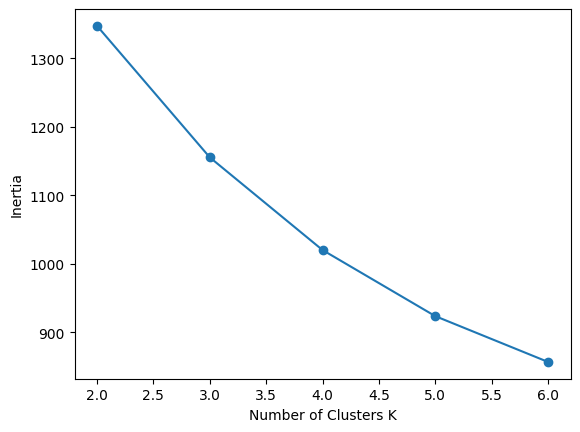

In [175]:
plt.plot(Ks, inertias, marker = "o")
plt.xlabel("Number of Clusters K")
plt.ylabel("Inertia")

I shall now look at mean shift, the above shows the elbow plot where there is diminishing returns after about K = 4

In [103]:
rng = np.random.default_rng(42)

group1 = rng.normal(
    loc=[0, 0],
    scale=0.5,
    size=(200, 2)
)

group2 = rng.normal(
    loc=[4, 3],
    scale=0.6,
    size=(200, 2)
)

X = np.concatenate([group1, group2])



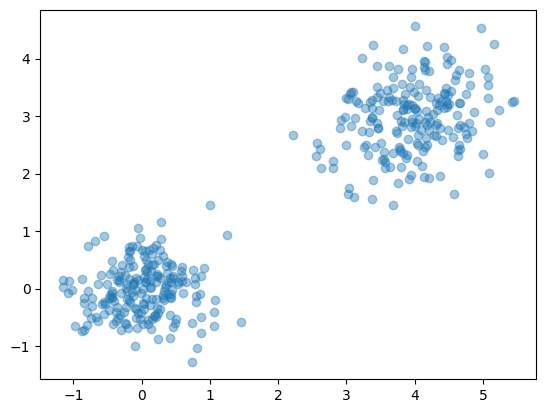

In [104]:
plt.scatter(X[:,0], X[:,1], alpha = 0.4)

In [116]:
from sklearn.cluster import MeanShift

ms = MeanShift(bandwidth = 10)
ms.fit(X)

labels_ms = ms.labels_
centres_ms = ms.cluster_centers_

print(np.bincount(labels_ms))
print(np.unique(labels_ms))
print(centres_ms)
print(len(np.unique(labels_ms)))

[400]
[0]
[[1.98675097 1.47919864]]
1


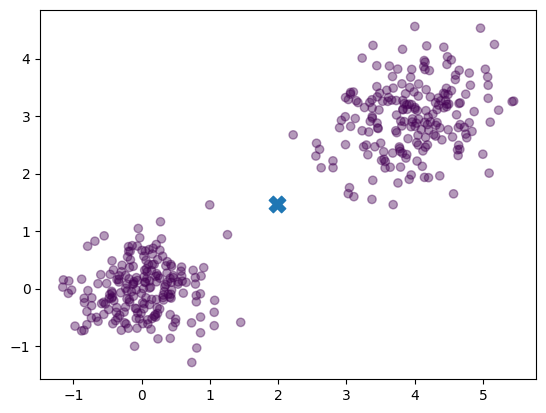

In [117]:
plt.scatter(X[:,0], X[:,1], alpha = 0.4, c = labels_ms)

plt.scatter(centres_ms[:,0], centres_ms[:,1], s = 140, marker= "X")

Main thing here is that we never told Mean shift the amount of clusters to look out for, it appeared through the chosen bandwidth.

In [120]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)

print(bandwidth)

1.0441848334830601


In [121]:
ms = MeanShift(bandwidth=bandwidth)
ms.fit(X)

labels_ms = ms.labels_
centres_ms = ms.cluster_centers_

print("Number of clusters:", len(np.unique(labels_ms)))
print("Counts:", np.bincount(labels_ms))

Number of clusters: 2
Counts: [200 200]


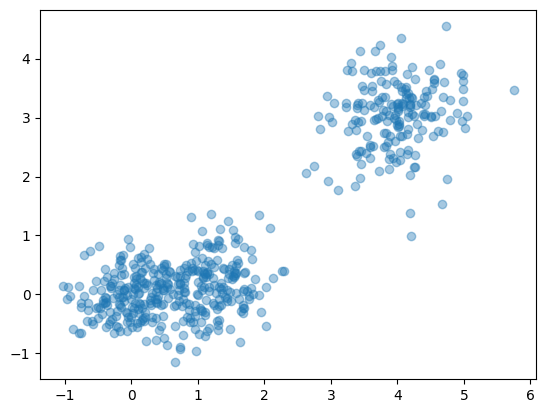

In [122]:
rng = np.random.default_rng(42)

group1 = rng.normal(
    loc=[0, 0],
    scale=0.45,
    size=(180, 2)
)

group2 = rng.normal(
    loc=[1.2, 0.2],
    scale=0.45,
    size=(180, 2)
)

group3 = rng.normal(
    loc=[4, 3],
    scale=0.55,
    size=(180, 2)
)

X = np.concatenate([group1, group2, group3])

plt.scatter(X[:, 0], X[:, 1], alpha=0.4)

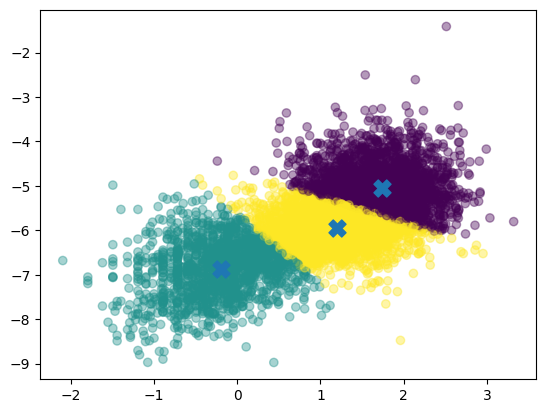

In [176]:
kmeans = KMeans(n_clusters= 3, n_init = 10, random_state= 1)

kmeans.fit(X)

labels_km = kmeans.labels_
centres_km = kmeans.cluster_centers_

plt.scatter(X[:,0], X[:,1], c = labels_km, alpha = 0.4)
plt.scatter(centres_km[:,0], centres_km[:,1], s = 150, marker = "X")

Number of clusters 2


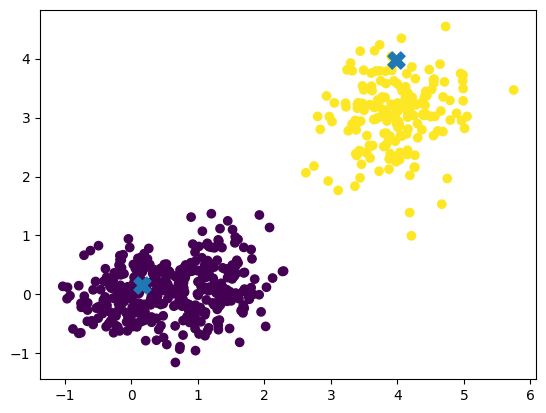

In [124]:
meanshift = MeanShift(bandwidth=0.8)
meanshift.fit(X)

labels_ms = meanshift.labels_
centres_ms = meanshift.cluster_centers_

print("Number of clusters", len(np.unique(labels_ms)))

plt.scatter(X[:,0], X[:,1], c = labels_ms)
plt.scatter(centres_ms[:,0], centres_ms[:,0], s = 150, marker = "X")

In [125]:
import requests
import numpy as np
from matplotlib import pyplot as plt

# Download catalogue
r = requests.get(
    "https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt"
)

with open("Summary_table.txt", "wb") as f:
    f.write(r.content)

# Read table
data = np.loadtxt(
    "Summary_table.txt",
    dtype="str",
    unpack=True
)

# Read column names
with open("Summary_table.txt", "r") as f:
    names = np.array([
        n.strip().replace(" ", "_")
        for n in f.readlines()[1]
        .replace("#", "")
        .replace("\n", "")
        .lstrip()
        .split("    ")
        if n.strip() != ""
    ])

print(names)
print(data.shape)

['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']
(15, 9164)


C:\Users\krist\AppData\Local\Temp\ipykernel_41100\1898079847.py:14: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt(


In [126]:
print(np.where(names == "T90"))

(array([6]),)


In [129]:
T90_raw = data[np.where(names == "T90")[0][0]]
print(T90_raw[:20])

['35.5850' '0.6560' '23.5520' '35.3290' '11.9680' '19.2640' '23.8080'
 '1.7920' '35.0720' '12.0320' '3.8400' '-999' '19.0080' '33.7920'
 '12.0320' '0.5760' '19.4560' '48.3850' '12.5440' '94.7220']


We can see this is loaded as strings

In [135]:
T90 = T90_raw.astype(float)

print("Total catalogue entries:", len(T90_raw))
print("Usable T90 measurements:", len(T90))
print("Minimum:", T90.min())
print("Maximum:", T90.max())


Total catalogue entries: 9164
Usable T90 measurements: 9164
Minimum: -999.0
Maximum: 2100.0


C:\Users\krist\AppData\Local\Temp\ipykernel_41100\3343020934.py:6: RuntimeWarning: invalid value encountered in log
  ax2.hist(np.log(T90), bins = 50)


(array([  1.,   0.,   4.,   1.,   2.,  12.,   7.,  15.,  32.,  38.,  23.,
         57., 108.,  88.,  86.,  91., 118., 151., 143., 122., 120., 138.,
        136., 147., 184., 192., 257., 316., 368., 419., 481., 532., 550.,
        571., 555., 523., 418., 322., 261., 197., 102.,  71.,  56.,  34.,
         16.,   8.,   7.,   1.,   1.,   1.]),
 array([-4.82831374, -4.57875361, -4.32919348, -4.07963336, -3.83007323,
        -3.5805131 , -3.33095297, -3.08139285, -2.83183272, -2.58227259,
        -2.33271247, -2.08315234, -1.83359221, -1.58403208, -1.33447196,
        -1.08491183, -0.8353517 , -0.58579157, -0.33623145, -0.08667132,
         0.16288881,  0.41244893,  0.66200906,  0.91156919,  1.16112932,
         1.41068944,  1.66024957,  1.9098097 ,  2.15936982,  2.40892995,
         2.65849008,  2.90805021,  3.15761033,  3.40717046,  3.65673059,
         3.90629072,  4.15585084,  4.40541097,  4.6549711 ,  4.90453122,
         5.15409135,  5.40365148,  5.65321161,  5.90277173,  6.15233186,
 

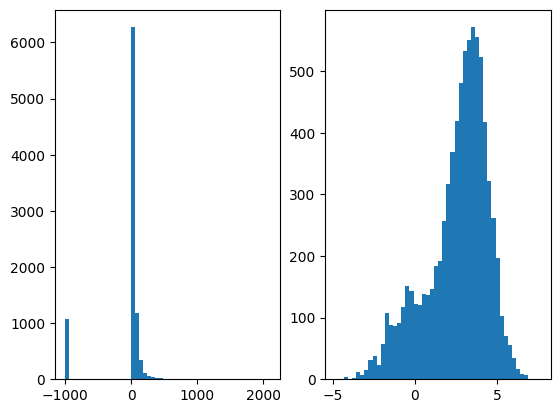

In [138]:
ax1 = plt.subplot(121)

ax1.hist(T90, bins = 50)

ax2 = plt.subplot(122)
ax2.hist(np.log(T90), bins = 50)

In [140]:
bad = T90[T90 <= 0]

print(np.unique(bad, return_counts=True))

(array([-999.]), array([1081]))


In [141]:
valid = np.isfinite(T90) & (T90 > 0)
T90_clean = T90[valid]

print("Total catalogue entries:", len(T90))
print("Usable T90 measurements:", len(T90_clean))
print("Minimum:", T90_clean.min())
print("Maximum:", T90_clean.max())

Total catalogue entries: 9164
Usable T90 measurements: 8083
Minimum: 0.008
Maximum: 2100.0


(array([  1.,   0.,   4.,   1.,   2.,  12.,   7.,  15.,  32.,  38.,  23.,
         57., 108.,  88.,  86.,  91., 118., 151., 143., 122., 120., 138.,
        136., 147., 184., 192., 257., 316., 368., 419., 481., 532., 550.,
        571., 555., 523., 418., 322., 261., 197., 102.,  71.,  56.,  34.,
         16.,   8.,   7.,   1.,   1.,   1.]),
 array([-2.09691001, -1.98852743, -1.88014484, -1.77176225, -1.66337967,
        -1.55499708, -1.4466145 , -1.33823191, -1.22984932, -1.12146674,
        -1.01308415, -0.90470157, -0.79631898, -0.68793639, -0.57955381,
        -0.47117122, -0.36278863, -0.25440605, -0.14602346, -0.03764088,
         0.07074171,  0.1791243 ,  0.28750688,  0.39588947,  0.50427205,
         0.61265464,  0.72103723,  0.82941981,  0.9378024 ,  1.04618499,
         1.15456757,  1.26295016,  1.37133274,  1.47971533,  1.58809792,
         1.6964805 ,  1.80486309,  1.91324567,  2.02162826,  2.13001085,
         2.23839343,  2.34677602,  2.45515861,  2.56354119,  2.67192378,
 

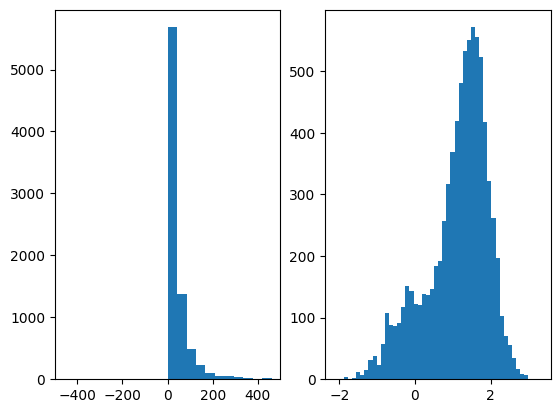

In [145]:
ax1 = plt.subplot(121)

ax1.hist(T90_clean, bins = 50)
ax1.set_xlim((-500, 500))

ax2 = plt.subplot(122)
ax2.hist(np.log10(T90_clean), bins = 50)

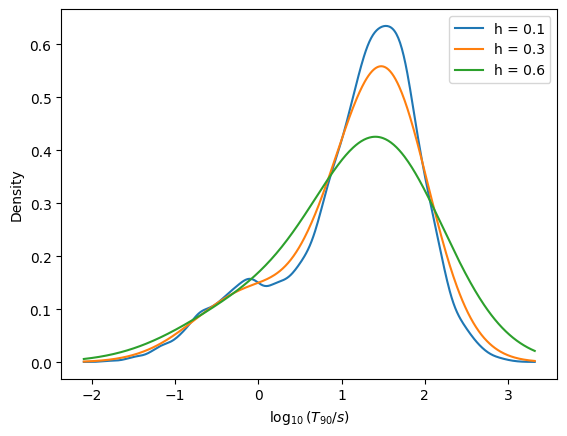

In [147]:
logT90 = np.log10(T90_clean)

xgrid = np.linspace(logT90.min(), logT90.max(), 500)

def kde_sklearn(data, xgrid, bandwidth=1.0):
    kde = KernelDensity(bandwidth=bandwidth)
    kde.fit(data[:, np.newaxis])

    log_pdf = kde.score_samples(xgrid[:, np.newaxis])

    return np.exp(log_pdf)

pdf_01 = kde_sklearn(logT90, xgrid, bandwidth=0.1)
pdf_03 = kde_sklearn(logT90, xgrid, bandwidth=0.3)
pdf_06 = kde_sklearn(logT90, xgrid, bandwidth=0.6)

plt.plot(xgrid, pdf_01, label="h = 0.1")
plt.plot(xgrid, pdf_03, label="h = 0.3")
plt.plot(xgrid, pdf_06, label="h = 0.6")

plt.xlabel(r"$\log_{10}(T_{90}/s)$")
plt.ylabel("Density")
plt.legend()

In [151]:
logT90 = np.log10(T90_clean)
print(logT90.shape)
X_T90 = logT90[:, np.newaxis]
print(X_T90.shape)

(8083,)
(8083, 1)


In [157]:
kmeans = KMeans(n_clusters = 2, n_init = 10, random_state = 1)

kmeans.fit(X_T90)

labels_km = kmeans.labels_
centres_km = kmeans.cluster_centers_

print(np.bincount(labels_km))
print(centres_km)

centres_seconds = 10**centres_km
print("Cluster centres in log10(s):")
print(centres_km)

print("Cluster centres in seconds:")
print(centres_seconds)

[2066 6017]
[[-0.03526763]
 [ 1.52093922]]
Cluster centres in log10(s):
[[-0.03526763]
 [ 1.52093922]]
Cluster centres in seconds:
[[ 0.92200308]
 [33.18480139]]


In [160]:
centres_sorted = np.sort(centres_km.ravel())

threshold_log = (centres_sorted[0] + centres_sorted[1]) / 2

threshold_seconds = 10**threshold_log

print(threshold_log)
print(threshold_seconds)

0.7428357966384312
5.531409313953631


This is the threshold between the classes

In [163]:
centres_seconds = 10**centres_sorted
print(centres_seconds)

[ 0.92200308 33.18480139]


In [164]:
from sklearn.cluster import MeanShift, estimate_bandwidth

bw = estimate_bandwidth(X_T90)
print("estimated bandwidth:", bw)

estimated bandwidth: 0.5165973144844593


In [165]:
ms = MeanShift(bandwidth=bw)
ms.fit(X_T90)

labels_ms = ms.labels_
centres_ms = ms.cluster_centers_

print("number of clusters:", len(np.unique(labels_ms)))
print("cluster counts:", np.bincount(labels_ms))
print("centres in log-space:", centres_ms.ravel())
print("centres in seconds:", 10**centres_ms.ravel())

number of clusters: 1
cluster counts: [8083]
centres in log-space: [1.48840641]
centres in seconds: [30.78976779]


In [166]:
for bw_test in [0.1, 0.2, 0.3, 0.5, 0.8]:
    ms = MeanShift(bandwidth=bw_test)
    ms.fit(X_T90)

    print(bw_test, len(np.unique(ms.labels_)), 10**ms.cluster_centers_.ravel())

0.1 26 [3.99602108e+01 3.14312453e+01 2.25231877e+01 5.14787821e+01
 1.37467599e+01 9.95589193e+00 7.89277715e+00 3.67144750e+00
 7.18562650e-01 5.60727394e-01 1.99016367e+00 1.54575585e+00
 1.17243633e+00 3.14549408e-01 4.40510348e-01 2.14613229e-01
 1.41707135e-01 7.71953833e-02 5.02479467e-02 6.68817828e+02
 3.35371327e-02 1.65156717e-02 1.05936460e+03 2.38315685e-02
 2.10000000e+03 8.00000000e-03]
0.2 10 [3.43375379e+01 6.98901358e-01 1.14658658e+00 1.89133066e+00
 3.99349048e-01 2.37482448e-01 1.00653572e-01 1.93701380e-02
 2.10000000e+03 8.00000000e-03]
0.3 2 [33.58494204  1.23258249]
0.5 1 [30.63090686]
0.8 1 [28.15600642]


In [167]:
for bw_test in np.arange(0.25, 0.51, 0.025):

    ms = MeanShift(bandwidth=bw_test)
    ms.fit(X_T90)

    centres = 10**ms.cluster_centers_.ravel()

    print(np.round(bw_test, 3), len(np.unique(ms.labels_)), np.round(centres, 2)
    )

0.25 5 [3.184e+01 1.450e+00 6.600e-01 3.200e-01 1.000e-02]
0.275 3 [35.2   1.29  0.67]
0.3 2 [33.58  1.23]
0.325 3 [33.33  1.48  0.66]
0.35 3 [32.62  1.71  0.71]
0.375 2 [31.55  1.35]
0.4 2 [31.31  0.95]
0.425 2 [31.24  1.  ]
0.45 2 [30.69  1.08]
0.475 1 [31.06]
0.5 1 [30.63]


In [169]:
ms = MeanShift(bandwidth=0.4)
ms.fit(X_T90)

print("Centres:", 10**ms.cluster_centers_.ravel())
print("Counts:", np.bincount(ms.labels_))

Centres: [31.31390723  0.94684769]
Counts: [6022 2061]


In [170]:
ms = MeanShift(bandwidth=0.35)
ms.fit(X_T90)

print("Centres:", 10**ms.cluster_centers_.ravel())
print("Counts:", np.bincount(ms.labels_))

Centres: [32.61541442  1.70973025  0.70954085]
Counts: [5671 1336 1076]


The duration distribution shows evidence for at least two broad sub-populations. K-means applied to $\log_{10}T_{90}$ gives characteristic durations of approximately $0.92$ s and $33.2$ s. Mean Shift independently recovers approximately $1$ s and $31$ s over a stable range of bandwidths, although smaller bandwidths resolve additional substructure and larger bandwidths merge the populations.

Let us look at other sections like fluence and redshift:

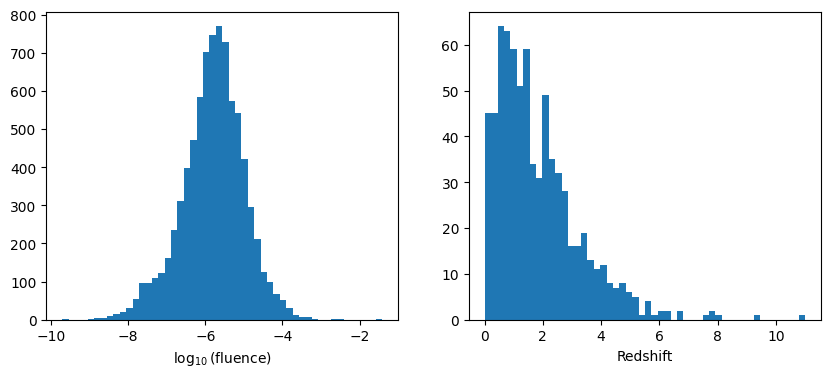

In [171]:
fluence_raw = data[np.where(names == "fluence")[0][0]]
redshift_raw = data[np.where(names == "redshift")[0][0]]

fluence = fluence_raw.astype(float)
redshift = redshift_raw.astype(float)

fluence_clean = fluence[np.isfinite(fluence) & (fluence > 0)]
redshift_clean = redshift[np.isfinite(redshift) & (redshift > 0)]

fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].hist(np.log10(fluence_clean), bins=50)
ax[0].set_xlabel(r"$\log_{10}(\mathrm{fluence})$")

ax[1].hist(redshift_clean, bins=50)
ax[1].set_xlabel("Redshift")

plt.show()

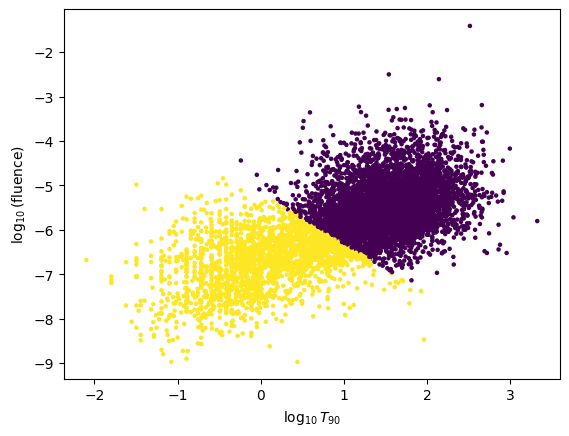

In [173]:
from sklearn.preprocessing import StandardScaler
T90_all = T90_raw.astype(float)
fluence_all = fluence_raw.astype(float)

mask = (
    np.isfinite(T90_all) &
    np.isfinite(fluence_all) &
    (T90_all > 0) &
    (fluence_all > 0)
)

X = np.column_stack([
    np.log10(T90_all[mask]),
    np.log10(fluence_all[mask])
])

X_scaled = StandardScaler().fit_transform(X)

km2 = KMeans(n_clusters=2, n_init=10, random_state=1)
labels_2d = km2.fit_predict(X_scaled)

plt.scatter(X[:,0], X[:,1], c=labels_2d, s=5)
plt.xlabel(r"$\log_{10}T_{90}$")
plt.ylabel(r"$\log_{10}(\mathrm{fluence})$")
plt.show()

### Resources

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html